In [2]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load the videos
video_paths_full = [
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/autogrid/enhanced_videos/enhanced_video_autogrid_clip5_autogrid_front_vid_2025-07-21_19-28-45.mp4",
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/autogrid/enhanced_videos/enhanced_video_autogrid_clip5_autogrid_side_vid_2025-07-21_19-25-39.mp4",
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/silicon_chip/enhanced_videos/enhanced_video_silicon_chip_clip5_oldSiChip_front_vid_2025-07-21_18-43-57.mp4",
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/silicon_chip/enhanced_videos/enhanced_video_silicon_chip_clip5_oldSiChip_side_vid_2025-07-21_18-39-26.mp4",
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/cryosilico/enhanced_videos/enhanced_video_cryosilico_clip5_newSiChip_side_vid_2025-07-21_19-02-35.mp4",
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/cryosilico/enhanced_videos/enhanced_video_cryosilico_clip5_newSiChip_front_vid_2025-07-21_19-08-45.mp4",
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/cryosilico/enhanced_videos/enhanced_video_cryosilico_clip5_newSiChip_front_vid_2025-07-21_19-08-45.mp4",
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/cryosilico/enhanced_videos/enhanced_video_cryosilico_clip5_newSiChip_side_vid_2025-07-21_19-02-35.mp4",
]

def get_first_frame(video_path):
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    
    # Check if the video was opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None
    
    # Read the first frame
    ret, frame = cap.read()
    
    # Release the video capture object
    cap.release()
    
    if not ret:
        print(f"Error: Could not read frame from video {video_path}")
        return None
    
    # convert to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return gray_frame

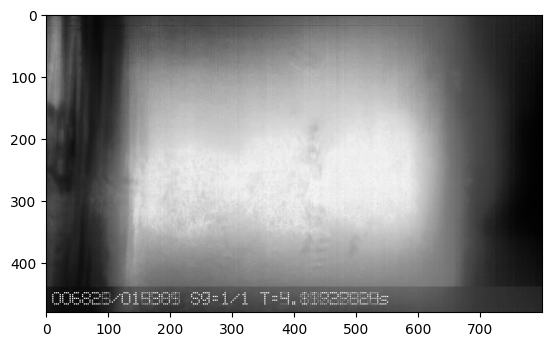

In [5]:
import numpy as np 
frames_list = [] 
for video_path in video_paths_full:
    frame = get_first_frame(video_path)
    if frame is not None:
        frames_list.append(frame)

frames_list = np.array(frames_list)

frames_mean = np.mean(frames_list, axis=0)
plt.imshow(frames_mean, cmap='gray')


Length of interface: 2.00 mm


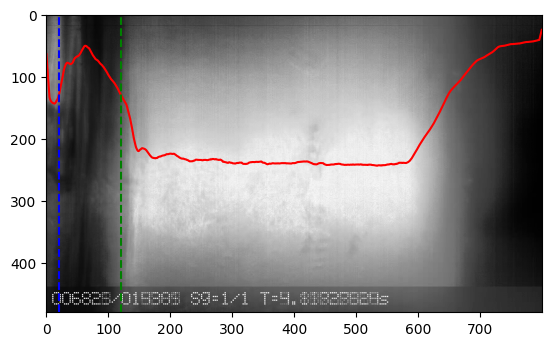

In [15]:
projection_y = np.percentile(frames_mean, 97, axis=0)
uniform_filter_size = 10
projection_y = np.convolve(projection_y, np.ones(uniform_filter_size)/uniform_filter_size, mode='same')
x1 = 20
x2 = 120
plt.imshow(frames_mean, cmap='gray')
plt.plot(projection_y, color='red', label='Projection Y')
plt.axvline(x=x1, color='blue', linestyle='--', label='x1')
plt.axvline(x=x2, color='green', linestyle='--', label='x2')
length_of_interface_pixel = abs(x2 - x1)
reference_apix = 20e-6
length_of_interface_m = length_of_interface_pixel * reference_apix
print(f"Length of interface: {length_of_interface_m*1e3:.2f} mm")

In [11]:
surface_level_detected

4